# Does the Pareto Principle (80/20 Rule) Apply to my Streaming History?

In [48]:
# necessary imports

import pandas as pd
from utils import historySplit
import dotenv
import os
import requests
import matplotlib as plt
import matplotlib.pyplot as plot
import numpy as np

## Top Artists

Manually getting top artist data again, ensuring as much accuracy as possible due to rounding of the top artists csv

In [89]:
df = pd.read_csv("Spotify Extended Streaming History/cleaned/cleaned-history.csv")

In [90]:
allArtists = df['master_metadata_album_artist_name'].unique()
topArtists = pd.DataFrame({'Artists': allArtists})
topArtists['time_played'] = topArtists['Artists'].apply(lambda x: df[df['master_metadata_album_artist_name'] == x]['ms_played'].sum())
topArtists.sort_values(by='time_played', ascending=False, inplace=True)
topArtists.reset_index(drop=True, inplace=True)

In [91]:
n_rows = 0.2 * len(topArtists)
top20Percent = topArtists.head(int(n_rows))

In [92]:
twentyTimePlayed = top20Percent['time_played'].sum()
allTimePlayed = topArtists['time_played'].sum()

In [94]:
twentyPercentTimePlayed = (twentyTimePlayed / allTimePlayed) * 100
print(f"My top 20% of artists account for {twentyPercentTimePlayed:.2f}% of my total listening time.")

My top 20% of artists account for 94.27% of my total listening time.


In [95]:
topArtists['time_played'] = topArtists['time_played'] / 1000  # convert to seconds
topArtists['time_played'] = topArtists['time_played'] / 60  # convert to minutes
topArtists['time_played'] = topArtists['time_played'].round(2)

My top artists actually exceed the Pareto principle by a noticeable margin!

## Top Tracks

Favouring speed of processing, using the top tracks csv already saved as processing the results often takes excessive amounts of time

In [96]:
topTracks = pd.read_csv("Spotify Extended Streaming History/cleaned/top-tracks.csv")

In [97]:
n_tracks = 0.2 * len(topTracks)
top20PercentTracks = topTracks.head(int(n_tracks))

In [98]:
twentyPercentTracksPlayed = top20PercentTracks['time_played'].sum()
allTracksPlayed = topTracks['time_played'].sum()
twentyPercentTracksPlayedPercentage = (twentyPercentTracksPlayed / allTracksPlayed) * 100
print(f"My top 20% of tracks account for {twentyPercentTracksPlayedPercentage:.2f}% of my total listening time.")

My top 20% of tracks account for 82.98% of my total listening time.


The Pareto principle still holds for the top 20th percentile of tracks listened, but there is not as much of a bias as with my top artists.

## Top Genres

Using the pre-sorted top genres csv file to reduce API calls, the accuracy dropoff is negligible given the scale of the numbers in the genres csv.

In [18]:
topGenres = pd.read_csv("Spotify Extended Streaming History/cleaned/top-genres.csv")

In [19]:
n_genres = 0.2 * len(topGenres)
top20PercentGenres = topGenres.head(int(n_genres))

In [20]:
twentyPercentGenres = top20PercentGenres['time_played'].sum()
allGenresPlayed = topGenres['time_played'].sum()
twentyPercentGenresPlayedPercentage = (twentyPercentGenres / allGenresPlayed) * 100
print(f"My top 20% of genres account for {twentyPercentGenresPlayedPercentage:.2f}% of my total listening time.")

My top 20% of genres account for 67.38% of my total listening time.


The Pareto principle does not hold on my top genres listened! Partially this can be chalked up to the crowd-sourced genres on last.fm including many specific subgenres that will outweigh the top 20% (i.e. abstract hip-hop, jazz rap, math rock etc). However, the main cause that affects this is likely that each song is tagged with multiple genres. To fix this and see the real distribution of my genre listening, I will need to re-run the last.fm API calls and only count the primary genre of each song, as opposed to the top 3.

In [99]:
genreArtists = topArtists.head(150)

In [100]:
# get genre for each artist using Last.fm API
dotenv.load_dotenv()
LASTFM_API_KEY = os.getenv("LASTFM_API_KEY")

artist_genre_lookup = {}

url = "http://ws.audioscrobbler.com/2.0/"

# Iterate through each artist and fetch their top tags (genres) from Last.fm
for index, artist_name in enumerate(genreArtists['Artists']):
    try:
        # Prepare the payload for the Last.fm API request
        payload = {
            'method': 'artist.getTopTags',
            'artist': artist_name,
            'api_key': LASTFM_API_KEY,
            'format': 'json'
        }
        
        # Make the API request to Last.fm
        response = requests.get(url, params=payload)
        data = response.json()
        
        # Extract the top tags (genres) from the response
        toptags_container = data.get('toptags', {})
        raw_tags_list = toptags_container.get('tag', [])
        
        # Extract the top genre (if available) and convert them to lowercase
        genres = [tag['name'].lower() for tag in raw_tags_list[:1]] # get top genre
        
        
        if not genres:
            genres = ['unknown']
            
        artist_genre_lookup[artist_name] = genres
    
    # Handle specific exceptions
    except Exception as e:
        print(f"Skipping {artist_name} due to an unexpected error: {e}")
        continue

In [101]:
genreArtists['genres'] = genreArtists['Artists'].map(artist_genre_lookup)
genreArtists['genres'] = genreArtists['genres'].fillna({i: ['unknown'] for i in genreArtists.index})
genreArtists = genreArtists.explode('genres', ignore_index=True)
genre_sum = genreArtists.groupby('genres')['time_played'].sum().reset_index()
genre_sum.sort_values(by='time_played', ascending=False, inplace=True)
genre_sum.reset_index(drop=True, inplace=True)

In [102]:
genre_sum.head(20) # numbers are still in ms

,genres,time_played
0,hip-hop,54747.56
1,electronic,37141.03
2,folk,22419.89
3,post-punk,20219.69
4,rock,16517.71
5,lo-fi,13194.52
6,classic rock,12345.05
7,indie rock,11436.49
8,singer-songwriter,11219.97
9,pop,11037.25


In [103]:
n_genres = 0.2 * len(genre_sum)
top20PercentGenres = genre_sum.head(int(n_genres))

In [104]:
genreTwentyPlayed = top20PercentGenres['time_played'].sum()
allGenresPlayed = genre_sum['time_played'].sum()
twentyPercentTimePlayed = (genreTwentyPlayed / allGenresPlayed) * 100
print(f"My top 20% of tracks account for {twentyPercentTimePlayed:.2f}% of my total listening time.")

My top 20% of tracks account for 57.71% of my total listening time.


In [ ]:
genre_sum['time_played'] = genre_sum['time_played'] / 1000  # convert to seconds
genre_sum['time_played'] = genre_sum['time_played'] / 60  # convert to minutes
genre_sum['time_played'] = genre_sum['time_played'].round(2)

Now that each genre is counted properly, my genre listening actually fails to meet the pareto principle. Less than 60% of my listening time is accounted for by my top 20th percentile of genres, implying a large diversity of genres in my listening.

## Visualisation of Data

In [ ]:
def plot_pareto(df, name_col, time_col, title):
    # Sort descending and calculate cumulative percentages
    df_sorted = df.sort_values(by=time_col, ascending=False).reset_index(drop=True)
    df_sorted['cum_pct'] = (df_sorted[time_col].cumsum() / df_sorted[time_col].sum()) * 100
    df_sorted['pct_rank'] = ((df_sorted.index + 1) / len(df_sorted)) * 100

    fig, ax = plot.subplots(figsize=(10, 5))

    # Plot the full normalized cumulative line (0% to 100% of entities)
    ax.plot(df_sorted['pct_rank'], df_sorted['cum_pct'], color='firebrick', linewidth=2.5, label=f'Cumulative {title} Time')

    # 80/20 Pareto Reference Lines
    ax.axhline(80, color='gray', linestyle='--', alpha=0.7, label='80% Listening Time Threshold')
    ax.axvline(20, color='gray', linestyle=':', alpha=0.7, label='20% Top Entities Cutoff')

    # Formatting axes & labels
    ax.set_title(f'Normalized Pareto Analysis: {title}', fontsize=14, pad=12)
    ax.set_xlabel(f'Percentage of Total {title} (%)', fontsize=11)
    ax.set_ylabel('Cumulative Listening Time (%)', fontsize=11)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right')

    plot.show()

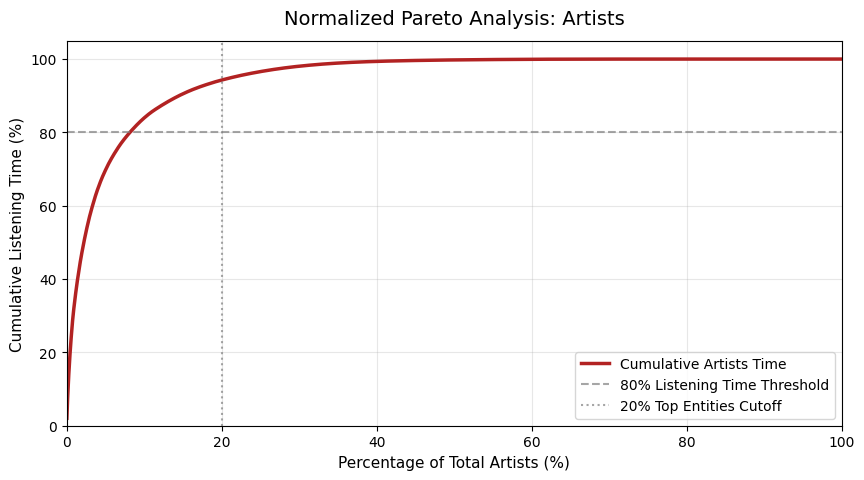

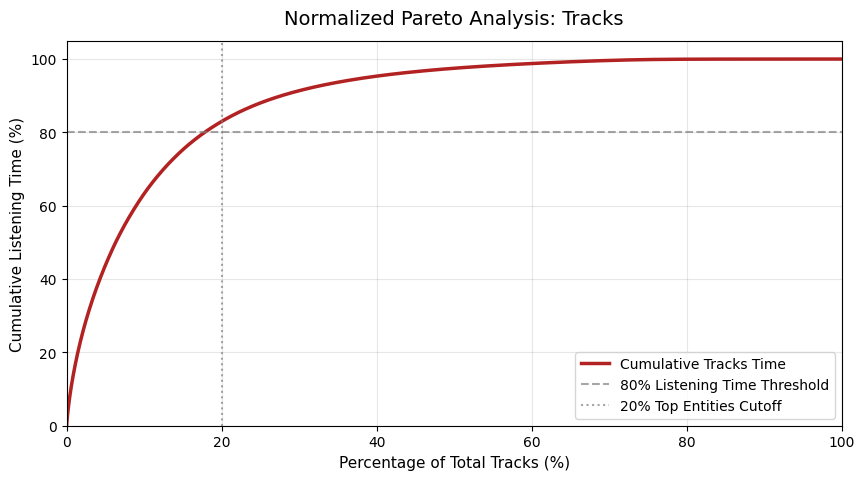

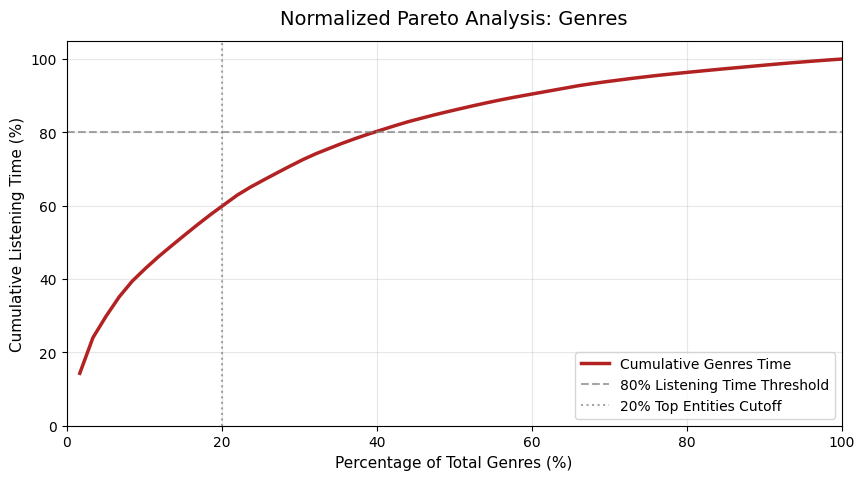

In [ ]:
plot_pareto(topArtists, 'Artists', 'time_played', 'Artists')
plot_pareto(topTracks, 'Tracks', 'time_played', 'Tracks')
plot_pareto(genre_sum, 'genres', 'time_played', 'Genres')